# HRES 0.1° Analysis — flash-aurora Engine

Same setup as the upstream [Microsoft Aurora HRES 0.1° example](microsoft-aurora/docs/example_hres_0.1.ipynb):

- **Date:** 2022-05-11
- **Initial condition:** 06:00 UTC (hours 00:00 + 06:00)
- **Rollout:** 2 steps → 12:00 and 18:00 UTC
- **Model:** `AuroraHighRes` / `aurora-0.1-finetuned` via preset `hres_0.1`

The Engine **`GribHresAnalysisAdapter`** accepts either:

1. **GRIB files** downloaded from UCAR RDA (same URLs as upstream), or
2. **NetCDF cache** under `<ASSET_ROOT>/hres_0.1/` (`{day}-surface-level.nc`, `{day}-atmospheric-00.nc`, `{day}-atmospheric-06.nc`).

It then **`batch.regrid(res=0.1)`** and injects static fields from `aurora-0.1-static.pickle` in `ASSET_ROOT`.

> **Asset root:** default is `./assets` under the working directory. Here we use the data disk in developing environment, comment `ASSET_ROOT = Path("/root/autodl-tmp/aurora")` in the setup cell to use your own disk.

## Prerequisites

1. **Extra packages:** `uv pip install cfgrib` (GRIB ingress; `requests` is used by the downloader).
2. **Checkpoint** and **`aurora-0.1-static.pickle`** under `ASSET_ROOT`, or Hugging Face download in the setup cell.
3. **GPU with sufficient VRAM** — 0.1° global grid is ~1801×3600; `AuroraEngine` uses a cross-process **GPU guard** (queue / share) under `<ASSET_ROOT>/.flash-aurora/gpu_guard/`.


In [1]:
from datetime import datetime
from pathlib import Path

from flash_aurora.engine import (
    DEFAULT_PRESETS,
    DataDownloader,
    HF_MIRROR_ENDPOINT,
)
from flash_aurora.engine.core.redaction import safe_path

PRESET = "hres_0.1"
VALID_TIME = datetime(2022, 5, 11, 6)
TIME_INDEX = 1
ROLLOUT_STEPS = 2

# Named tier or combo: backbone@encoder_decoder (see README).
INFERENCE_PRECISION = "bf16_mixed@fp32"

# Default: ./assets under the notebook working directory (created if missing).
ASSET_ROOT: Path | str | None = None

# Optional — absolute path to a mounted data disk with checkpoints/cache (uncomment to use):
ASSET_ROOT = Path("/root/autodl-tmp/aurora")

if ASSET_ROOT is not None:
    root = Path(ASSET_ROOT).expanduser()
    if not root.is_absolute():
        raise ValueError("ASSET_ROOT must be an absolute path")
    ASSET_ROOT = root.resolve()
else:
    ASSET_ROOT = (Path.cwd() / "assets").resolve()
    ASSET_ROOT.mkdir(parents=True, exist_ok=True)

variant = DEFAULT_PRESETS.get(PRESET).variant
CHECKPOINT_PATH = ASSET_ROOT / variant.checkpoint_filename
USE_HF_MIRROR = False  # True -> https://hf-mirror.com when huggingface.co is blocked

if CHECKPOINT_PATH.is_file():
    CHECKPOINT_ARG = CHECKPOINT_PATH
    ALLOW_HUB_DOWNLOAD = False
    HF_ENDPOINT = None
    print("checkpoint: local", safe_path(CHECKPOINT_PATH))
else:
    CHECKPOINT_ARG = None
    ALLOW_HUB_DOWNLOAD = True
    HF_ENDPOINT = HF_MIRROR_ENDPOINT if USE_HF_MIRROR else None
    print("checkpoint: missing locally; will download from Hugging Face")
    print("  target dir:", safe_path(ASSET_ROOT))
    print("  filename:", variant.checkpoint_filename)
    print("  hf_endpoint:", HF_ENDPOINT or "https://huggingface.co (default)")

downloader = DataDownloader.from_preset(PRESET, asset_root=ASSET_ROOT)
cache_dir = downloader.resolve_cache_dir()

print("cache_dir:", safe_path(cache_dir))
print("asset_root:", safe_path(ASSET_ROOT))
print("allow_hub_download:", ALLOW_HUB_DOWNLOAD)

from flash_aurora.engine.core.hub import HubDownloadOptions
from flash_aurora.engine.core.paths import AssetStore

# Static fields from Hugging Face (file lives in ASSET_ROOT, not under the ingress cache).
STATIC_PICKLE_PATH = ASSET_ROOT / variant.static_pickle
HF_OPTIONS = HubDownloadOptions(
    endpoint=HF_MIRROR_ENDPOINT if USE_HF_MIRROR else HF_ENDPOINT,
)
if STATIC_PICKLE_PATH.is_file():
    print("static_pickle: local", safe_path(STATIC_PICKLE_PATH))
else:
    print("static_pickle: missing locally; will download from Hugging Face")
    print("  target dir:", safe_path(ASSET_ROOT))
    print("  filename:", variant.static_pickle)
    print("  hf_endpoint:", HF_OPTIONS.endpoint or "https://huggingface.co (default)")
    STATIC_PICKLE_PATH = AssetStore(root=ASSET_ROOT).fetch_hub_file(
        variant.static_pickle,
        repo=variant.hf_repo,
        allow_download=True,
        explicit=ASSET_ROOT,
        hub=HF_OPTIONS,
    )
    print("static_pickle: ready", safe_path(STATIC_PICKLE_PATH))


checkpoint: local ~/autodl-tmp/aurora/aurora-0.1-finetuned.ckpt
cache_dir: ~/autodl-tmp/aurora/hres_0.1
asset_root: ~/autodl-tmp/aurora
allow_hub_download: False
static_pickle: local ~/autodl-tmp/aurora/aurora-0.1-static.pickle


## 1. Download IFS HRES 0.1° analysis (UCAR RDA)

`DataDownloader.ensure()` fetches the upstream UCAR RDA GRIB set into `<ASSET_ROOT>/hres_0.1/`:

- Surface/static: `surf_{var}_YYYY-MM-DD.grib`
- Atmospheric: `atmos_{var}_YYYY-MM-DD_HH.grib` for HH ∈ {00, 06, 12, 18}

Re-run is safe: existing files are skipped.


In [2]:
from pathlib import Path

from flash_aurora.engine import DownloadResult
from flash_aurora.engine.core.redaction import safe_path

missing = downloader.missing(VALID_TIME)

if missing:
    print("Missing GRIB files:", missing)
    result = downloader.ensure(VALID_TIME)
else:
    print("HRES 0.1 GRIB cache already complete under", safe_path(cache_dir))
    result = DownloadResult(
        cache_dir=cache_dir,
        paths=downloader.expected_paths(VALID_TIME),
        downloaded=(),
        skipped=tuple(downloader.expected_paths(VALID_TIME)),
    )

print("downloaded:", result.downloaded)
print("skipped:", result.skipped)
for key, path in result.paths.items():
    print(f"  {key}: {safe_path(path)}")


HRES 0.1 GRIB cache already complete under ~/autodl-tmp/aurora/hres_0.1
downloaded: ()
skipped: ('surface', 'atmospheric_00', 'atmospheric_06')
  surface: ~/autodl-tmp/aurora/hres_0.1/2022-05-11-surface-level.nc
  atmospheric_00: ~/autodl-tmp/aurora/hres_0.1/2022-05-11-atmospheric-00.nc
  atmospheric_06: ~/autodl-tmp/aurora/hres_0.1/2022-05-11-atmospheric-06.nc


## 2. Build initial condition

`InitialConditionBuilder` detects the GRIB cache, loads 00:00 + 06:00 fields, regrids to 0.1°, and attaches HF static pickle fields.


## 3. Load model and rollout

0.1° inference is memory-intensive. `engine.load()` acquires a GPU lease via the cross-process guard (small presets may share; `hres_0.1` queues until ~48 GiB is free). Call `engine.release_gpu()` when finished. Start with `bf16_mixed@fp32`.


In [3]:
import torch

from flash_aurora.engine import AuroraEngine, InitialConditionBuilder
from flash_aurora.aurora.model.inference_precision import describe_inference_config

engine = AuroraEngine.from_preset(
    PRESET,
    asset_root=ASSET_ROOT,
    checkpoint_path=CHECKPOINT_ARG,
    allow_hub_download=ALLOW_HUB_DOWNLOAD,
    hf_mirror=USE_HF_MIRROR,
    hf_endpoint=None if USE_HF_MIRROR else HF_ENDPOINT,
)

# Must be set before load() — see README "Inference precision tiers".
engine.config.inference_precision = INFERENCE_PRECISION
engine.config.gpu_rollout_steps = ROLLOUT_STEPS

request = downloader.ingest_request(
    VALID_TIME,
    time_index=TIME_INDEX,
    download=False,
)
builder = InitialConditionBuilder(engine.config)
batch = builder.from_source(request)
print("IC time:", batch.metadata.time)
print("spatial:", batch.spatial_shape)

engine.load()
print("device:", next(engine.model.parameters()).device)

cfg = engine.model.inference_config
if cfg is not None:
    print("inference tier:", cfg.config_label)
    print(describe_inference_config(cfg))

preds = []
with torch.inference_mode():
    for pred in engine.rollout_stream(batch, ROLLOUT_STEPS):
        preds.append(pred.to("cpu"))
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("predictions:", [str(p.metadata.time[0]) for p in preds])
engine.release_gpu()


IC time: (datetime.datetime(2022, 5, 11, 6, 0),)
spatial: torch.Size([1801, 3600])
device: cuda:0
inference tier: bf16_mixed@fp32
backbone matmul hybrid: BF16 attention QKV/proj + BF16 MLP; TF32 elsewhere; encoder/decoder matmul FP32 (native Perceiver SDPA); Triton layout+AdaLN; CuTe window attention (bfloat16); backbone activations float32
predictions: ['2022-05-11 12:00:00', '2022-05-11 18:00:00']


## 4. Visualize: Aurora vs HRES analysis

Compare predicted 2 m temperature against the downloaded `surf_2t` GRIB at forecast valid times.


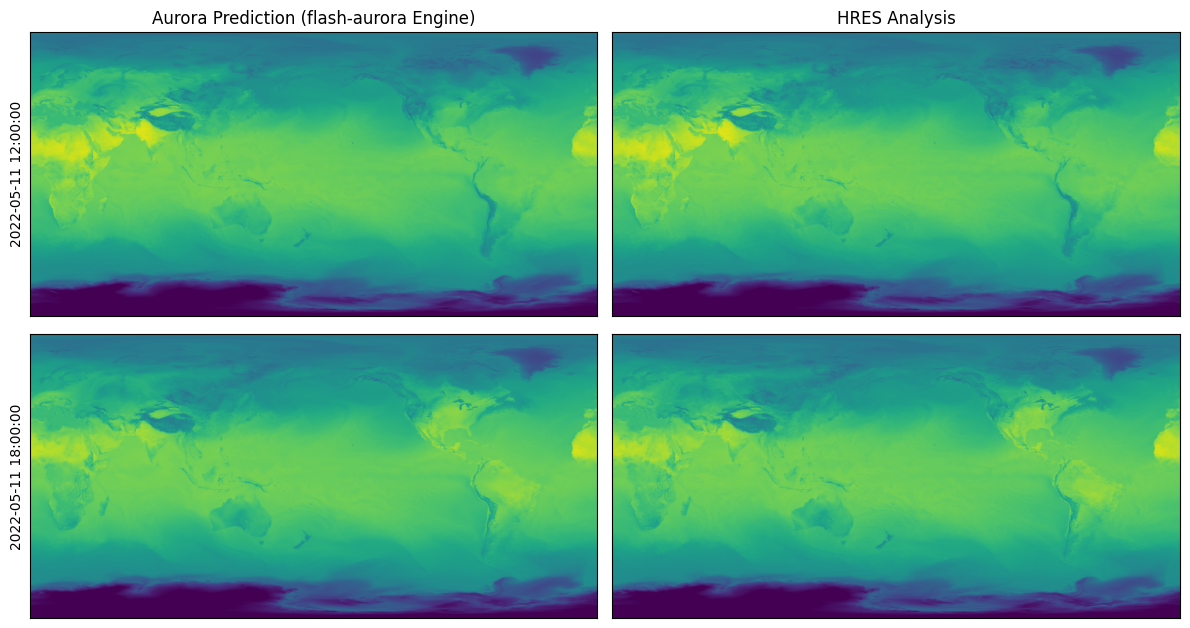

In [4]:
import matplotlib.pyplot as plt
import xarray as xr

truth = xr.open_dataset(
    cache_dir / VALID_TIME.strftime("surf_2t_%Y-%m-%d.grib"),
    engine="cfgrib",
)

fig, ax = plt.subplots(2, 2, figsize=(12, 6.5))

for i in range(ax.shape[0]):
    pred = preds[i]

    ax[i, 0].imshow(pred.surf_vars["2t"][0, 0].numpy() - 273.15, vmin=-50, vmax=50)
    ax[i, 0].set_ylabel(str(pred.metadata.time[0]))
    if i == 0:
        ax[i, 0].set_title("Aurora Prediction (flash-aurora Engine)")
    ax[i, 0].set_xticks([])
    ax[i, 0].set_yticks([])

    ref = truth["t2m"][2 + i].values
    ax[i, 1].imshow(ref - 273.15, vmin=-50, vmax=50)
    if i == 0:
        ax[i, 1].set_title("HRES Analysis")
    ax[i, 1].set_xticks([])
    ax[i, 1].set_yticks([])

plt.tight_layout()
plt.show()


## 5. (Optional) Export rollout to NetCDF

Writes one file per step under `<ASSET_ROOT>/output/hres_0.1/`.


In [5]:
# Model already released in section 3.
print("model device:", next(engine.model.parameters()).device)
print("gpu ticket:", engine._gpu_ticket)

# Re-allocate model to GPU
engine.model.to(engine.config.device)
import torch
torch.cuda.synchronize()
print("model device:", next(engine.model.parameters()).device)

# Export rollout to NetCDF
EXPORT_DIR = ASSET_ROOT / "output" / PRESET
paths = list(engine.rollout_and_export(batch, steps=ROLLOUT_STEPS, export_dir=EXPORT_DIR))
for p in paths:
    print(safe_path(p), p.is_file())
engine.release_gpu()

model device: cpu
gpu ticket: None
model device: cuda:0
~/autodl-tmp/aurora/output/hres_0.1/prediction-000.nc True
~/autodl-tmp/aurora/output/hres_0.1/prediction-001.nc True
